# 01 — 21cmFAST Single Simulation Test

Goal: run a minimal set of 21cmFAST coeval simulations, extract the
dimensionless 21 cm power spectrum Δ²₍₂₁₎(k, z), construct one feature
vector, and save the output for downstream pipeline testing.

In [10]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import py21cmfast as p21c

In [11]:
PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIGURES = PROJECT_ROOT / "figures"
LOGS = PROJECT_ROOT / "logs"

for path in [DATA_RAW, FIGURES, LOGS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", DATA_RAW)
print("Figures directory:", FIGURES)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression
Raw data directory: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw
Figures directory: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures


In [12]:
print("py21cmfast version:", p21c.__version__)

py21cmfast version: 4.1.1


In [13]:
astro_params = {
    "HII_EFF_FACTOR": 30.0,   # zeta: ionizing efficiency
    "ION_Tvir_MIN": 4.7,      # log10(Tvir / K)
    "R_BUBBLE_MAX": 15.0,     # R_mfp in Mpc
    "L_X": 40.5,              # X-ray luminosity proxy for f_X
}

cosmo_params = {
    "SIGMA_8": 0.81,          # structure-growth amplitude
}

user_params = {
    "HII_DIM": 64,
    "BOX_LEN": 100,
}

redshifts = [8.0, 10.0, 12.0]

print("Astrophysical parameters:")
for key, value in astro_params.items():
    print(f"  {key}: {value}")

print("\nCosmological parameters:")
for key, value in cosmo_params.items():
    print(f"  {key}: {value}")

print("\nRedshifts:", redshifts)

Astrophysical parameters:
  HII_EFF_FACTOR: 30.0
  ION_Tvir_MIN: 4.7
  R_BUBBLE_MAX: 15.0
  L_X: 40.5

Cosmological parameters:
  SIGMA_8: 0.81

Redshifts: [8.0, 10.0, 12.0]


In [14]:
metadata = {
    "astro_params": astro_params,
    "cosmo_params": cosmo_params,
    "user_params": user_params,
    "redshifts": redshifts,
    "observable": "dimensionless_21cm_power_spectrum",
    "simulation_type": "coeval",
}

metadata_path = DATA_RAW / "single_simulation_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata to:", metadata_path)

Saved metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/single_simulation_metadata.json


In [16]:
# v4-style 21cmFAST input object
# Start from built-in simple + small templates, then override our chosen parameters.

inputs = p21c.InputParameters.from_template(
    ["simple", "small"],
    random_seed=1234,

    # Cosmological parameter
    SIGMA_8=0.81,

    # Astrophysical parameters
    HII_EFF_FACTOR=30.0,   # zeta
    ION_Tvir_MIN=4.7,      # log10(Tvir / K)
    R_BUBBLE_MAX=15.0,     # R_mfp
    L_X=40.5,              # X-ray luminosity proxy for f_X
)

coeval_list = p21c.run_coeval(
    inputs=inputs,
    out_redshifts=redshifts,
    write=False,
    progressbar=True,
)

coeval_boxes = {box.redshift: box for box in coeval_list}

for z, box in coeval_boxes.items():
    print(f"Completed z = {z}")
    print("Brightness temperature shape:", box.brightness_temp.shape)

/opt/anaconda3/envs/sr21cm/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Completed z = 12.0
Brightness temperature shape: (64, 64, 64)
Completed z = 10.0
Brightness temperature shape: (64, 64, 64)
Completed z = 8.0
Brightness temperature shape: (64, 64, 64)


In [17]:
z_target = redshifts[0]

z_test = min(coeval_boxes.keys(), key=lambda zz: abs(zz - z_target))
bt = coeval_boxes[z_test].brightness_temp

print("Requested redshift:", z_target)
print("Selected available redshift:", z_test)
print("Brightness temperature type:", type(bt))
print("Shape:", bt.shape)
print("Min:", np.nanmin(bt))
print("Max:", np.nanmax(bt))
print("Mean:", np.nanmean(bt))
print("Std:", np.nanstd(bt))

Requested redshift: 8.0
Selected available redshift: 8.0
Brightness temperature type: <class 'numpy.ndarray'>
Shape: (64, 64, 64)
Min: 0.0
Max: 21.541206
Mean: 12.231991
Std: 9.162474


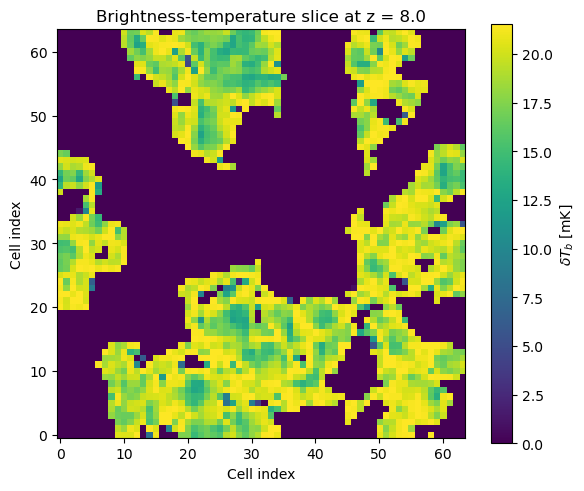

Saved slice figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/single_simulation_brightness_temp_slice.png


In [18]:
slice_index = bt.shape[0] // 2

plt.figure(figsize=(6, 5))
plt.imshow(bt[slice_index, :, :], origin="lower")
plt.colorbar(label=r"$\delta T_b$ [mK]")
plt.title(f"Brightness-temperature slice at z = {z_test}")
plt.xlabel("Cell index")
plt.ylabel("Cell index")
plt.tight_layout()

slice_path = FIGURES / "single_simulation_brightness_temp_slice.png"
plt.savefig(slice_path, dpi=300)
plt.show()

print("Saved slice figure to:", slice_path)

In [19]:
def compute_dimensionless_power_spectrum(field, box_len, n_kbins=20):
    """
    Compute an approximate spherically averaged dimensionless 3D power spectrum.

    This is a lightweight validation function for Notebook 01.
    For production dataset generation, we may later replace or cross-check this
    with a dedicated 21cmFAST/powerbox-based estimator.
    """

    field = np.asarray(field, dtype=float)

    if field.ndim != 3:
        raise ValueError("Input field must be a 3D array.")

    if not np.all(np.isfinite(field)):
        raise ValueError("Input field contains NaN or infinite values.")

    if field.shape[0] != field.shape[1] or field.shape[0] != field.shape[2]:
        raise ValueError("Input field must be cubic.")

    n = field.shape[0]

    fluct = field - np.mean(field)

    fft_field = np.fft.fftn(fluct)
    power_3d = np.abs(fft_field) ** 2 / n**6 * box_len**3

    kfreq = 2.0 * np.pi * np.fft.fftfreq(n, d=box_len / n)
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing="ij")
    k_mag = np.sqrt(kx**2 + ky**2 + kz**2)

    k_flat = k_mag.ravel()
    p_flat = power_3d.ravel()

    positive = k_flat > 0
    k_flat = k_flat[positive]
    p_flat = p_flat[positive]

    k_edges = np.logspace(
        np.log10(k_flat.min()),
        np.log10(k_flat.max()),
        n_kbins + 1
    )

    k_centers = np.sqrt(k_edges[:-1] * k_edges[1:])
    p_k = np.full(n_kbins, np.nan)

    for i in range(n_kbins):
        mask = (k_flat >= k_edges[i]) & (k_flat < k_edges[i + 1])
        if np.any(mask):
            p_k[i] = np.mean(p_flat[mask])

    delta2 = (k_centers**3 * p_k) / (2.0 * np.pi**2)

    valid = np.isfinite(delta2)

    return k_centers[valid], delta2[valid]

In [20]:
power_spectra = []

for z, box in coeval_boxes.items():

    field = box.brightness_temp

    k, delta2 = compute_dimensionless_power_spectrum(
        field=field,
        box_len=user_params["BOX_LEN"],
        n_kbins=20,
    )

    power_spectra.append({
        "z": z,
        "k": k,
        "delta2": delta2,
    })

    print(f"z = {z}")
    print("  k shape:", k.shape)
    print("  Delta^2 shape:", delta2.shape)
    print("  Delta^2 min/max:", np.nanmin(delta2), np.nanmax(delta2))

z = 12.0
  k shape: (19,)
  Delta^2 shape: (19,)
  Delta^2 min/max: 0.5868954356238875 20.07081094873471
z = 10.0
  k shape: (19,)
  Delta^2 shape: (19,)
  Delta^2 min/max: 1.4484528641054295 39.88841910950836
z = 8.0
  k shape: (19,)
  Delta^2 shape: (19,)
  Delta^2 min/max: 7.310722205895103 52.55163747676168


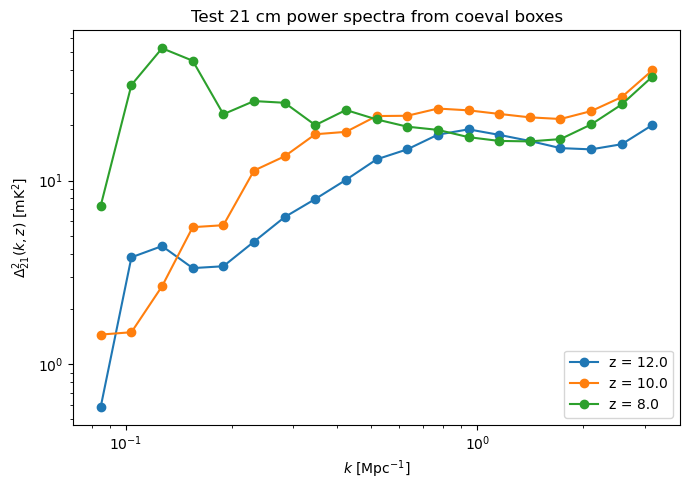

Saved power-spectrum figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/single_simulation_power_spectra.png


In [21]:
plt.figure(figsize=(7, 5))

for ps in power_spectra:
    plt.loglog(ps["k"], ps["delta2"], marker="o", label=f"z = {ps['z']}")

plt.xlabel(r"$k$ [Mpc$^{-1}$]")
plt.ylabel(r"$\Delta^2_{21}(k,z)$ [mK$^2$]")
plt.title(r"Test 21 cm power spectra from coeval boxes")
plt.legend()
plt.tight_layout()

ps_path = FIGURES / "single_simulation_power_spectra.png"
plt.savefig(ps_path, dpi=300)
plt.show()

print("Saved power-spectrum figure to:", ps_path)

In [22]:
feature_vector = []

feature_names = []

for ps in power_spectra:
    z = ps["z"]

    for k_val, delta_val in zip(ps["k"], ps["delta2"]):
        feature_vector.append(delta_val)

        feature_names.append(
            f"delta2_z{z:.1f}_k{k_val:.5f}"
        )

feature_vector = np.array(feature_vector, dtype=float)

print("Feature vector shape:", feature_vector.shape)
print("Number of feature names:", len(feature_names))
print("First five feature names:", feature_names[:5])
print("First five feature values:", feature_vector[:5])

Feature vector shape: (57,)
Number of feature names: 57
First five feature names: ['delta2_z12.0_k0.08491', 'delta2_z12.0_k0.10379', 'delta2_z12.0_k0.12686', 'delta2_z12.0_k0.15507', 'delta2_z12.0_k0.18954']
First five feature values: [0.58689544 3.81812464 4.39464559 3.33443725 3.41235873]


In [23]:
feature_vector_path = DATA_RAW / "single_simulation_feature_vector.npy"
feature_names_path = DATA_RAW / "single_simulation_feature_names.csv"

np.save(feature_vector_path, feature_vector)

feature_names_df = pd.DataFrame({
    "feature_index": np.arange(len(feature_names)),
    "feature_name": feature_names,
})

feature_names_df.to_csv(feature_names_path, index=False)

print("Saved feature vector to:", feature_vector_path)
print("Saved feature names to:", feature_names_path)

Saved feature vector to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/single_simulation_feature_vector.npy
Saved feature names to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/single_simulation_feature_names.csv


In [24]:
rows = []

for ps in power_spectra:
    z = ps["z"]

    for k_val, delta_val in zip(ps["k"], ps["delta2"]):

        rows.append({
            "z": z,
            "k": k_val,
            "delta2_21": delta_val,
        })

power_df = pd.DataFrame(rows)

power_csv_path = DATA_RAW / "single_simulation_power_spectra.csv"

power_df.to_csv(power_csv_path, index=False)

power_df.head()

,z,k,delta2_21
0,12.0,0.084910,0.586895
1,12.0,0.103787,3.818125
2,12.0,0.126861,4.394646
3,12.0,0.155065,3.334437
4,12.0,0.189540,3.412359


In [25]:
loaded_feature_vector = np.load(feature_vector_path)

loaded_power_df = pd.read_csv(power_csv_path)

loaded_feature_names = pd.read_csv(feature_names_path)

print("Loaded feature vector shape:", loaded_feature_vector.shape)
print("Loaded power-spectrum table shape:", loaded_power_df.shape)
print("Loaded feature-name table shape:", loaded_feature_names.shape)

assert loaded_feature_vector.shape == feature_vector.shape
assert len(loaded_feature_names) == len(feature_vector)
assert len(loaded_power_df) == len(feature_vector)

print("All saved outputs validated successfully.")

Loaded feature vector shape: (57,)
Loaded power-spectrum table shape: (57, 3)
Loaded feature-name table shape: (57, 2)
All saved outputs validated successfully.


In [26]:
print("=" * 60)
print("Notebook 01 completed successfully.")
print("=" * 60)

print("Simulation type: coeval boxes")
print("Redshifts:", redshifts)
print("Number of redshift slices:", len(redshifts))
print("k bins per redshift:", len(power_spectra[0]["k"]))
print("Total feature dimension:", feature_vector.shape[0])

print("\nGenerated files:")
print(" -", feature_vector_path)
print(" -", feature_names_path)
print(" -", power_csv_path)
print(" -", metadata_path)
print(" -", slice_path)
print(" -", ps_path)

Notebook 01 completed successfully.
Simulation type: coeval boxes
Redshifts: [8.0, 10.0, 12.0]
Number of redshift slices: 3
k bins per redshift: 19
Total feature dimension: 57

Generated files:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/single_simulation_feature_vector.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/single_simulation_feature_names.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/single_simulation_power_spectra.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/single_simulation_metadata.json
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/single_simulation_brightness_temp_slice.png
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/single_simulation_power_spectra.png
